In [1]:
import os
os.getcwd()

'c:\\Users\\giovanni.sgaravatti\\Bruegel Gitlab\\2021-11-european-natural-gas-imports'

In [27]:
Share_point = r'C:\Users\giovanni.sgaravatti\Bruegel\Research - 2021-11 European natural gas imports\Code\Imports' # Gio
# Share_point = r'C:\Users\giovanni.sgaravatti\Bruegel\Research - 2021-11 European natural gas imports\Code\Imports' # Ben

In [28]:
os.chdir(Share_point)

### Dependencies

In [4]:
import json
import requests
import pandas as pd
import numpy as np

from datetime import datetime
from datetime import date, timedelta
from dateutil.relativedelta import relativedelta

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.dates import DateFormatter
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import seaborn as sns

import eurostat  # python wrapper for taking data.
import time

In [29]:
eu27 = pd.read_excel('working_data\eu27.xlsx')

today = date.today()

d1 = '2020-01-01'
# d2 = '2023-06-30'
d2 = today.strftime("%Y-%m-%d")


converter = 10300000   ## KWh to M3m --> 10.3 KWh/m^3
converterTJ = 277778
kwhtwh = 0.000000001

AttributeError: 'str' object has no attribute 'today'

In [30]:
d2

'2023-07-14'

In [31]:
(60000000*30)/1000000000

1.8

In [32]:
#manual list of points on Entsog. 
both = pd.read_excel('working_data\pointsSAFE_EU27.xlsx',sheet_name='UA')

#I am stripping out the useful part from the URL / api call. 
identifiers = []
for num in range(1,len(both['both'])):
    idt = both['both'][num][93:].split("&",1)[0]
    identifiers.append(idt)

In [33]:
both

,both
0,https://transparency.entsog.eu/api/v1/operatio...
1,https://transparency.entsog.eu/api/v1/operatio...
2,https://transparency.entsog.eu/api/v1/operatio...
3,https://transparency.entsog.eu/api/v1/operatio...
4,https://transparency.entsog.eu/api/v1/operatio...
5,https://transparency.entsog.eu/api/v1/operatio...


In [34]:
dates = []
values = []
direction = []
operator = []
point = []
labels = []

urls = []
ids = []

for idt in identifiers:
    # print(idt)
    try:
        url = 'https://transparency.entsog.eu/api/v1/operationalData?forceDownload=true&pointDirection={}&from={}&to={}&indicator=Physical%20Flow&periodType=day&timezone=CET&limit=-1&dataset=1&directDownload=true'.format(idt,d1,d2)      
        r = requests.get(url)
        data = r.json()
        op = data['operationalData']

        for item in op:
            date = item['periodFrom'][:10]
            value = item['value']
            drc = item['directionKey']
            opr = item['operatorKey']
            pt = item['pointKey']
            label = item['pointLabel']

            dates.append(date)
            values.append(value)
            direction.append(drc)
            operator.append(opr)
            point.append(pt)
            labels.append(label)
            urls.append(url)
            ids.append(idt)
            
    except Exception as e:
        print(idt)          
        # print(e)
        # print(r.status_code)

In [35]:
df = pd.DataFrame()
df['dates'] = dates
df['values'] = values
df['direction'] = direction
df['operator'] = operator
df['location'] = point
df['label'] = labels
df['country'] = df['operator'].str[:2]

In [36]:
df.replace('', np.NaN)  #we set missing values to the numpy notation, NaN - easier to work with. 
df['values'] = pd.to_numeric(df['values'])  #because of initial missing values, the dataframe column was not integer. 
#We need to set it to integer to work with. 

In [37]:
df = df.sort_values(by='dates')

In [38]:
df['location'].unique()

array(['ITP-00421', 'ITP-00154', 'ITP-00307', 'ITP-10006', 'ITP-10008',
       'ITP-00087'], dtype=object)

In [39]:
#Merge with IEA point location data. Now we also know where the gas is coming from. 
mapping = pd.read_excel('working_data\locationsSAFE.xlsx',sheet_name='UA')
mapping = mapping[['location','exportcountry']] 
dfmerge = df.merge(mapping,on='location') ## this was deleting all values not matched up ... 

#### Ukraine flows

In [40]:
dfmerge.label.unique()

array(['Budince', 'Ungheni',
       'Beregdaróc 800 (HU) - Beregovo (UA) (HU>UA)',
       'VIP Bereg (HU) / VIP Bereg (UA)', 'GCP GAZ-SYSTEM/UA TSO',
       'Isaccea (RO) - Orlovka (UA) I'], dtype=object)

In [41]:
# UA imports from EU
## Slovakia
slov = df[(df['label']=='Budince')&(df['direction']=='exit')]
slov.set_index(pd.DatetimeIndex(slov['dates']),inplace=True)
slov = slov.sort_index()
## Poland
pol = df[(df.label=='GCP GAZ-SYSTEM/UA TSO')& (df.direction == 'exit')]
pol.set_index(pd.DatetimeIndex(pol['dates']),inplace=True)
pol = pol.sort_index()
# Hungary 
hungary = ['VIP Bereg (HU) / VIP Bereg (UA)']
hung = df[(df.label.isin(hungary))&(df.operator =='HU-TSO-0001')& (df.direction == 'exit')]
hung.set_index(pd.DatetimeIndex(hung['dates']),inplace=True)
hung = hung.sort_index()
# Moldova
mold_1 = df[(df.label=='Isaccea (RO) - Orlovka (UA) I')&(df.operator=='UA-TSO-0001')]
mold_2 = df[(df.label=='Ungheni')&(df.operator=='RO-TSO-0001')]
mold = pd.concat([mold_1,mold_2])
mold.set_index(pd.DatetimeIndex(mold['dates']),inplace=True)
mold = mold.sort_index()


In [42]:
df.country.unique()

array(['SK', 'RO', 'HU', 'PL', 'UA'], dtype=object)

In [45]:
import matplotlib.dates as mdates

In [55]:
df.head()

,dates,values,direction,operator,location,label,country
5192,2020-01-01,119474144.0,exit,SK-TSO-0001,ITP-00421,Budince,SK
3903,2020-01-01,0.0,exit,RO-TSO-0001,ITP-00154,Ungheni,RO
1888,2020-01-01,0.0,exit,HU-TSO-0001,ITP-00307,Beregdaróc 800 (HU) - Beregovo (UA) (HU>UA),HU
1889,2020-01-02,0.0,exit,HU-TSO-0001,ITP-00307,Beregdaróc 800 (HU) - Beregovo (UA) (HU>UA),HU
3904,2020-01-02,0.0,exit,RO-TSO-0001,ITP-00154,Ungheni,RO


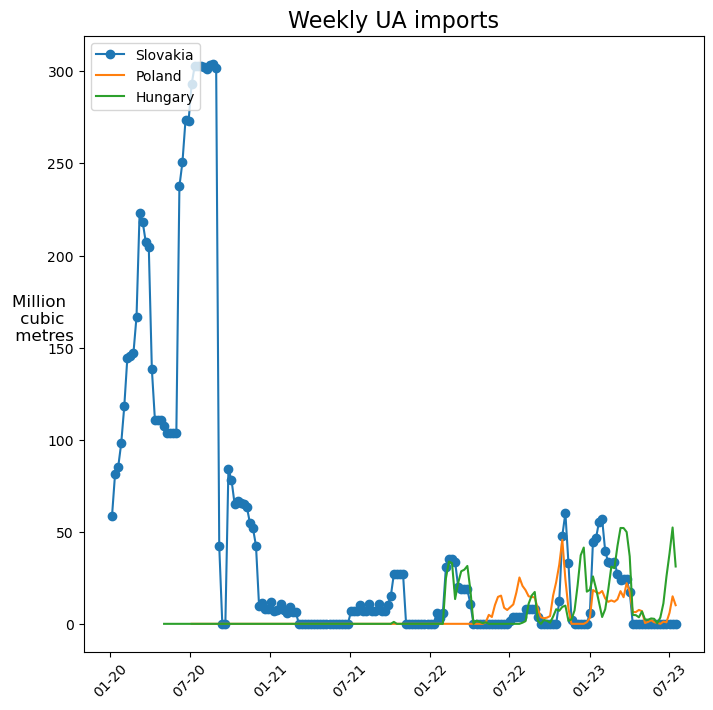

In [70]:
fig, ax = plt.subplots(figsize=(8, 8))
slov_plt = slov['2020':]['values'].groupby(pd.Grouper(freq='W')).sum(numeric_only=True)/converter
hung_plt = hung['2020':]['values'].groupby(pd.Grouper(freq='W')).sum(numeric_only=True)/converter
mold_plt = mold['2020':]['values'].groupby(pd.Grouper(freq='W')).sum(numeric_only=True)/converter
pol_plt = pol['2020':]['values'].groupby(pd.Grouper(freq='W')).sum(numeric_only=True)/converter

total_eu = slov_plt+hung_plt+pol_plt

ax.plot(slov_plt, label='Slovakia',marker='o')
ax.plot(pol_plt,label='Poland')
ax.plot(hung_plt,label='Hungary')
# ax.plot(mold_plt,label='Moldovia')

date_form1 = DateFormatter("%m-%y")
ax.xaxis.set_major_formatter(date_form1)
# ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
# ax.xaxis.set_major_locator(mdates.DayLocator(interval=5))
plt.xticks(rotation=45)

plt.title('Weekly UA imports',fontsize='16')
plt.ylabel('Million \n cubic \n metres',fontsize=12,rotation=0)
plt.legend(loc='upper left')

plt.show()

In [66]:
d = {'Slovakia':slov_plt,'Poland':pol_plt,'Hungary':hung_plt,'Total EU (exc RO)':total_eu, 'Moldova':mold_plt} 
dd = pd.DataFrame(data=d)

In [67]:
import os
os.chdir(r'C:\Users\giovanni.sgaravatti\Bruegel\Research - 2021-11 European natural gas imports\Data\Imports\UA imports')

In [68]:
dd = dd.round(2)
dd.to_csv('reverse flows into UA {}.csv'.format(today))